In [2]:
# 1. 한글 폰트 설치 (Colab 환경일 경우 아래 주석 3줄을 해제하고 실행하세요)
# !sudo apt-get install -y fonts-nanum
# !sudo fc-cache -fv
# !rm ~/.cache/matplotlib -rf

# 2. 필수 라이브러리 임포트
import pandas as pd
import numpy as np
import glob
import re
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from IPython.display import display

# 3. 그래프 한글 및 마이너스 기호 설정
plt.rc('font', family='NanumBarunGothic') # 로컬(Windows)이라면 'Malgun Gothic'으로 변경
plt.rcParams['axes.unicode_minus'] = False

print("✅ 라이브러리 임포트 및 환경 설정 완료!")

✅ 라이브러리 임포트 및 환경 설정 완료!


1단계: 유가 데이터 전처리 및 시각화 (22년 1월 ~ 24년 12월)

In [12]:
oil_df_gasoline = pd.read_csv('oil_data/주유소_지역별_평균판매가격(휘발유 22.1~24.12).csv', encoding='cp949')
oil_df_diesel = pd.read_csv('oil_data/주유소_지역별_평균판매가격(경유 22.1~24.12).csv', encoding='cp949')

In [13]:
oil_df_diesel

,구분,서울
0,2022년01월,1535.69
1,2022년02월,1614.18
2,2022년03월,1907.90
3,2022년04월,1972.80
4,2022년05월,2018.48
5,2022년06월,2151.39
6,2022년07월,2135.77
7,2022년08월,1945.22
8,2022년09월,1920.22
9,2022년10월,1904.10


In [14]:
oil_df_gasoline

,구분,서울
0,2022년01월,1705.21
1,2022년02월,1782.07
2,2022년03월,2011.74
3,2022년04월,2036.85
4,2022년05월,2027.54
5,2022년06월,2151.49
6,2022년07월,2082.96
7,2022년08월,1858.73
8,2022년09월,1799.95
9,2022년10월,1737.66


In [15]:
def clean_date(date_str):
    return date_str.replace('년', '-').replace('월', '')

oil_df_gasoline['oil_month'] = oil_df_gasoline['구분'].apply(clean_date)
oil_df_diesel['oil_month'] = oil_df_diesel['구분'].apply(clean_date)

oil_df_gasoline = oil_df_gasoline.rename(columns={'서울': 'gasoline_price'})[['oil_month', 'gasoline_price']]
oil_df_diesel = oil_df_diesel.rename(columns={'서울': 'diesel_price'})[['oil_month', 'diesel_price']]

oil_df = pd.merge(oil_df_gasoline, oil_df_diesel, on='oil_month', how='inner')
oil_df['average_price'] = (oil_df['gasoline_price'] + oil_df['diesel_price']) / 2

oil_df

,oil_month,gasoline_price,diesel_price,average_price
0,2022-01,1705.21,1535.69,1620.450
1,2022-02,1782.07,1614.18,1698.125
2,2022-03,2011.74,1907.90,1959.820
3,2022-04,2036.85,1972.80,2004.825
4,2022-05,2027.54,2018.48,2023.010
5,2022-06,2151.49,2151.39,2151.440
6,2022-07,2082.96,2135.77,2109.365
7,2022-08,1858.73,1945.22,1901.975
8,2022-09,1799.95,1920.22,1860.085
9,2022-10,1737.66,1904.10,1820.880


In [16]:
# 시차(Lag) 적용: 유가 발생 월 + 3개월 = 전기차 등록 타겟 월
oil_df['date_obj'] = pd.to_datetime(oil_df['oil_month'])
oil_df['target_ev_month'] = (oil_df['date_obj'] + pd.DateOffset(months=3)).dt.strftime('%Y-%m')

oil_df

,oil_month,gasoline_price,diesel_price,average_price,date_obj,target_ev_month
0,2022-01,1705.21,1535.69,1620.450,2022-01-01,2022-04
1,2022-02,1782.07,1614.18,1698.125,2022-02-01,2022-05
2,2022-03,2011.74,1907.90,1959.820,2022-03-01,2022-06
3,2022-04,2036.85,1972.80,2004.825,2022-04-01,2022-07
4,2022-05,2027.54,2018.48,2023.010,2022-05-01,2022-08
5,2022-06,2151.49,2151.39,2151.440,2022-06-01,2022-09
6,2022-07,2082.96,2135.77,2109.365,2022-07-01,2022-10
7,2022-08,1858.73,1945.22,1901.975,2022-08-01,2022-11
8,2022-09,1799.95,1920.22,1860.085,2022-09-01,2022-12
9,2022-10,1737.66,1904.10,1820.880,2022-10-01,2023-01


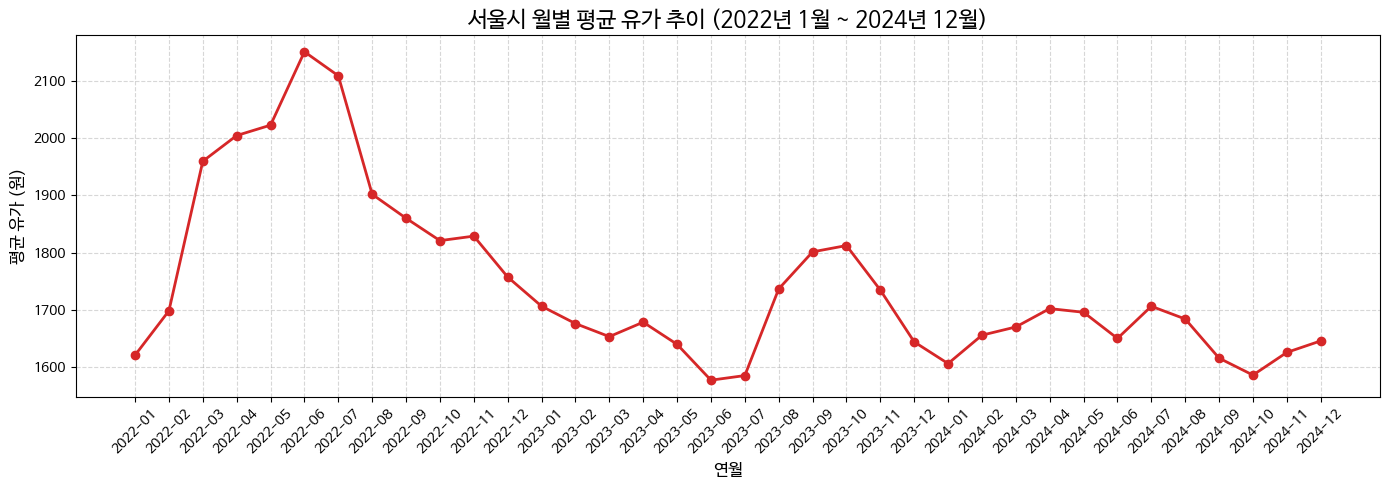

✅ 유가 데이터 전처리 미리보기:


,oil_month,target_ev_month,average_price
0,2022-01,2022-04,1620.450
1,2022-02,2022-05,1698.125
2,2022-03,2022-06,1959.820
3,2022-04,2022-07,2004.825
4,2022-05,2022-08,2023.010


In [17]:
# 4. [시각화] 36개월 유가 추이 선 그래프

plt.figure(figsize=(14, 5))
plt.plot(oil_df['oil_month'], oil_df['average_price'], color='tab:red', marker='o', linewidth=2)
plt.title('서울시 월별 평균 유가 추이 (2022년 1월 ~ 2024년 12월)', fontsize=16)
plt.xlabel('연월', fontsize=12)
plt.ylabel('평균 유가 (원)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("✅ 유가 데이터 전처리 미리보기:")
display(oil_df[['oil_month', 'target_ev_month', 'average_price']].head())

2단계: 전기차 데이터 전처리 및 시각화 (22년 3월 ~ 25년 3월)

In [18]:
file_list = glob.glob('car_data/2*.*월*.xlsx')
df_list = []

In [20]:
#파일명에서 날짜 추출
for file in file_list:
    match = re.search(r'(\d{2})\.(\d+)월', file)
    if match:
        year_short = match.group(1) 
        month_val = match.group(2).zfill(2) # '7' -> '07'
        
        # 22 -> 2022, 23 -> 2023으로 변환
        year_full = "20" + year_short
        year_month = f"{year_full}-{month_val}"
    else:
        continue
        
    df = pd.read_excel(file, skiprows=7, engine='openpyxl')
    
    df = df.loc[:, ~df.columns.astype(str).str.contains('^Unnamed')] #병합 셀 처리
    
    # 병합 셀 결측치 채우기
    if '시군구별' in df.columns:
        df['시군구별'] = df['시군구별'].ffill()
        df['연료별'] = df['연료별'].ffill()
        
    df['ev_month'] = year_month
    df_list.append(df)

    # 데이터 합치기 및 필터링
car_df_total = pd.concat(df_list, ignore_index=True)
car_df_total = car_df_total[car_df_total['시군구별'] != '합 계']

ev_df = car_df_total[car_df_total['연료별'].astype(str) == '전기'].copy()
ev_df['계'] = pd.to_numeric(ev_df['계'], errors='coerce')

In [21]:
car_df_total

,시군구별,연료별,용도별,승 용,승 합,화 물,특 수,계,ev_month
1,종로구,CNG,비사업용,6,4,19,0,29,2022-10
2,종로구,CNG,사업용,0,84,0,0,84,2022-10
3,종로구,경유,비사업용,9961,2998,3604,151,16714,2022-10
4,종로구,경유,사업용,158,157,663,74,1052,2022-10
5,종로구,기타연료,비사업용,1,27,59,31,118,2022-10
...,...,...,...,...,...,...,...,...,...
41275,강동구,휘발유,비사업용,29531,16,112,0,29659,2025-03
41276,강동구,휘발유,사업용,56,0,0,0,56,2025-03
41277,강동구,휘발유(무연),비사업용,55687,18,32,0,55737,2025-03
41278,강동구,휘발유(무연),사업용,334,0,0,0,334,2025-03


In [22]:
ev_df

,시군구별,연료별,용도별,승 용,승 합,화 물,특 수,계,ev_month
10,종로구,전기,비사업용,602,0,71,0,673,2022-10
11,종로구,전기,사업용,33,11,37,0,81,2022-10
32,중구,전기,비사업용,834,4,604,0,1442,2022-10
33,중구,전기,사업용,452,0,85,0,537,2022-10
53,용산구,전기,비사업용,902,2,85,0,989,2022-10
...,...,...,...,...,...,...,...,...,...
41221,강남구,전기,사업용,6358,9,172,0,6539,2025-03
41244,송파구,전기,비사업용,4325,11,379,7,4722,2025-03
41245,송파구,전기,사업용,569,97,247,0,913,2025-03
41267,강동구,전기,비사업용,2882,9,302,2,3195,2025-03


In [23]:
# 월별 합산 및 신규 등록 대수 계산
monthly_ev = ev_df.groupby('ev_month')['계'].sum().reset_index()
monthly_ev = monthly_ev.rename(columns={'계': 'total_ev'})
monthly_ev = monthly_ev.sort_values('ev_month')

monthly_ev['new_ev'] = monthly_ev['total_ev'].diff()

monthly_ev

,ev_month,total_ev,new_ev
0,2022-03,86412,NaN
1,2022-04,90266,3854.0
2,2022-05,93446,3180.0
3,2022-06,96724,3278.0
4,2022-07,99180,2456.0
5,2022-08,102480,3300.0
6,2022-09,107596,5116.0
7,2022-10,110670,3074.0
8,2022-11,114702,4032.0
9,2022-12,118654,3952.0


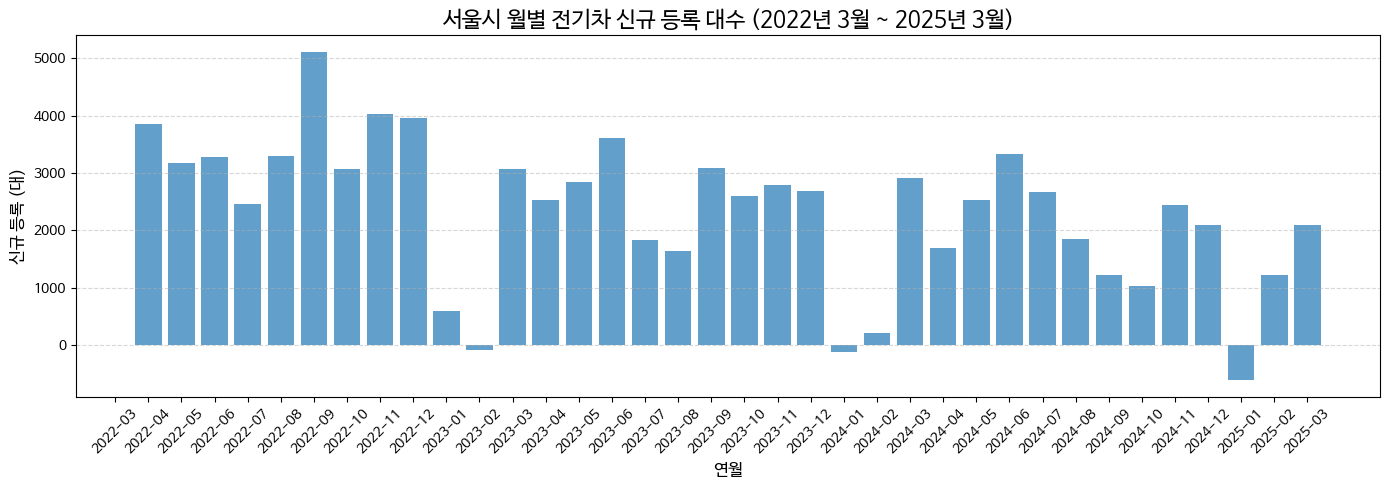

✅ 전기차 데이터 전처리 미리보기:


,ev_month,total_ev,new_ev
0,2022-03,86412,NaN
1,2022-04,90266,3854.0
2,2022-05,93446,3180.0
3,2022-06,96724,3278.0
4,2022-07,99180,2456.0


In [24]:
# 4. [시각화] 36개월 전기차 신규 등록 막대그래프
plt.figure(figsize=(14, 5))
plt.bar(monthly_ev['ev_month'], monthly_ev['new_ev'], color='tab:blue', alpha=0.7)
plt.title('서울시 월별 전기차 신규 등록 대수 (2022년 3월 ~ 2025년 3월)', fontsize=16)
plt.xlabel('연월', fontsize=12)
plt.ylabel('신규 등록 (대)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("✅ 전기차 데이터 전처리 미리보기:")
display(monthly_ev.head())

3단계: 데이터 병합 및 가설 검증 진행

In [29]:
# 1. 3개월 시차를 기준으로 두 데이터 병합
final_df = pd.merge(monthly_ev, oil_df, left_on='ev_month', right_on='target_ev_month', how='inner')
final_df = final_df.dropna(subset=['new_ev', 'average_price'])

x_oil = final_df['average_price']
y_ev = final_df['new_ev']

# 2. 통계적 유의성 검정 (피어슨 및 스피어만)
pearson_coef, pearson_p = pearsonr(x_oil, y_ev)
spearman_coef, spearman_p = spearmanr(x_oil, y_ev)

print("=== 통계적 유의성 검정 결과 ===")
print(f"- 피어슨 상관계수 (선형 관계): {pearson_coef:.4f} (p-value: {pearson_p:.4f})")
print(f"- 스피어만 상관계수 (순위 관계): {spearman_coef:.4f} (p-value: {spearman_p:.4f})\n")

=== 통계적 유의성 검정 결과 ===
- 피어슨 상관계수 (선형 관계): 0.3305 (p-value: 0.0490)
- 스피어만 상관계수 (순위 관계): 0.2420 (p-value: 0.1551)



In [30]:
alpha = 0.05
print("[최종 데이터 분석 결론]")
if pearson_p < alpha or spearman_p < alpha:
    direction = "양(+)" if pearson_coef > 0 else "음(-)"
    print(f"결론: 유의수준 {alpha}에서 p-value가 기준치 미만이므로 가설이 통계적으로 유의미하게 지지됩니다.")
    print(f"해석: 3개월 전의 평균 유가와 당월 전기차 신규 등록 대수 사이에는 유의미한 {direction}의 상관관계가 존재합니다.")
else:
    print(f"결론: 유의수준 {alpha}에서 통계적으로 유의미한 관계를 찾지 못했습니다.")
    print("해석: 유가 데이터만으로는 3개월 뒤의 전기차 신규 등록 변동을 설명하기 어렵습니다. 보조금 등 다른 요인의 개입이 클 수 있습니다.")

[최종 데이터 분석 결론]
결론: 유의수준 0.05에서 p-value가 기준치 미만이므로 가설이 통계적으로 유의미하게 지지됩니다.
해석: 3개월 전의 평균 유가와 당월 전기차 신규 등록 대수 사이에는 유의미한 양(+)의 상관관계가 존재합니다.


최종 통합 이중 축 시각화

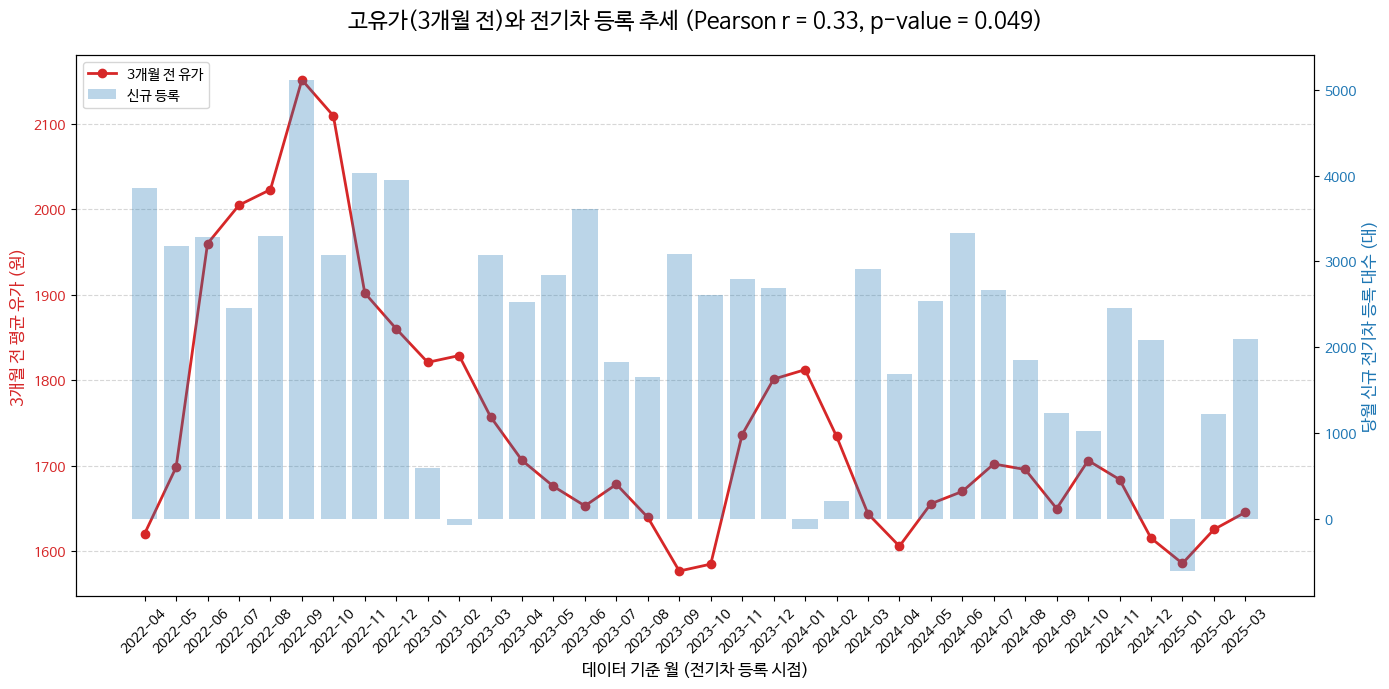

In [32]:
fig, ax1 = plt.subplots(figsize=(14, 7))

# 왼쪽 Y축 (유가)
color_oil = 'tab:red'
ax1.set_xlabel('데이터 기준 월 (전기차 등록 시점)', fontsize=12)
ax1.set_ylabel('3개월 전 평균 유가 (원)', color=color_oil, fontsize=12)
line1 = ax1.plot(final_df['ev_month'], final_df['average_price'], color=color_oil, marker='o', linewidth=2, label='3개월 전 유가')
ax1.tick_params(axis='y', labelcolor=color_oil)
plt.xticks(rotation=45)

# 오른쪽 Y축 (전기차)
ax2 = ax1.twinx()
color_ev = 'tab:blue'
ax2.set_ylabel('당월 신규 전기차 등록 대수 (대)', color=color_ev, fontsize=12)
bars = ax2.bar(final_df['ev_month'], final_df['new_ev'], color=color_ev, alpha=0.3, label='신규 등록')
ax2.tick_params(axis='y', labelcolor=color_ev)

plt.title(f"고유가(3개월 전)와 전기차 등록 추세 (Pearson r = {pearson_coef:.2f}, p-value = {pearson_p:.3f})", fontsize=16, pad=20)
ax1.grid(True, axis='y', linestyle='--', alpha=0.5)

# 범례 병합
lines = line1 + [bars]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.tight_layout()
plt.show()